In [185]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import numpy as np
import pandas as pd 
import re
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
import warnings
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split


warnings.filterwarnings("ignore")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predicting-the-cost-of-apartments/train_.csv
/kaggle/input/predicting-the-cost-of-apartments/test.csv


In [186]:
train_df = pd.read_csv('/kaggle/input/predicting-the-cost-of-apartments/train_.csv')
test_df = pd.read_csv('/kaggle/input/predicting-the-cost-of-apartments/test.csv')

data = train_df.copy()
test_data = test_df.copy()

In [187]:
def parse_header_details(value):
    if pd.isna(value):
        return None, None
    
    val = str(value).strip().lower()
    
    rooms_match = re.search(r"(\d+)[-\s]*комн", val)
    rooms = int(rooms_match.group(1)) if rooms_match else np.nan
    
    area_match = re.search(r"(\d+(\.\d+)?)\s*м2", val)
    area = float(area_match.group(1)) if area_match else np.nan
    
    return rooms, area

def parse_floor(value):
    if pd.isna(value):
        return None, None

    val = str(value).strip().lower()

    # цоколь и подвал → условно 0 этаж
    if val.startswith("цоколь"):
        mf = re.search(r"из\s*(\d+)", val)
        return 0, int(mf.group(1)) if mf else None

    if val.startswith("подвал"):
        mf = re.search(r"из\s*(\d+)", val)
        return 0, int(mf.group(1)) if mf else None

    # стандартный случай: X этаж из Y
    match = re.match(r"(\d+)\s*этаж из\s*(\d+)", val)
    if match:
        return int(match.group(1)), int(match.group(2))

    return None, None
    
def parse_house_info(value):
    if pd.isna(value):
        return None, None
    
    val = str(value).strip().lower()

    # Тип дома (берём всё до запятой — например "монолитный")
    house_type = re.split(r",", val)[0].strip()

    # Год постройки (если указан)
    year_match = re.search(r"(\d{3,4})\s*г", val)
    if year_match:
        year = int(year_match.group(1))
    else:
        year = np.nan

    return house_type, year
    
def fix_n_rooms(row):
    val = str(row["header_details"]).lower()
    
    if "6 и более" in val:
        return 6
    elif "свободная планировка" in val:
        return 1
    else:
        return row["n_rooms"]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # радиус Земли в км
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def process_documents(df, col="Правоустанавливающие документы"):
    #df["has_red_book"] = df[col].str.contains("красная книга", case=False, na=False).astype(int)
    #df["has_green_book"] = df[col].str.contains("зеленая книга", case=False, na=False).astype(int)
    #df["has_sale_contract"] = df[col].str.contains("д-продажи", case=False, na=False).astype(int)
    df["has_share_agreement"] = df[col].str.contains("договор долевого участия", case=False, na=False).astype(int)
    #df["has_inheritance"] = df[col].str.contains("наследство", case=False, na=False).astype(int)
    #df["has_technical_passport"] = df[col].str.contains("технический паспорт", case=False, na=False).astype(int)
    #df["has_commissioning_act"] = df[col].str.contains("акт ввода в эксплуатацию", case=False, na=False).astype(int)
    #df["has_gift_contract"] = df[col].str.contains("договор дарения", case=False, na=False).astype(int)
    return df

def extract_region(addr):
    if pd.isna(addr):
        return None
    
    addr = str(addr).strip()

    # 1. Село (с.) или деревня
    if addr.startswith("с. "):
        return "Село"   # можно оставить "Село" или "Село " + название
    
    # 2. Районные и областные центры
    if "область" in addr.lower():
        return addr.split(",")[0].strip()   # "Ошская область"
    
    # 3. Бишкек / Ош (оставляем только сам город)
    if addr.startswith("Бишкек"):
        return "Бишкек"
    if addr.startswith("Ош"):
        return "Ош"
    
    # 4. Иностранные метки
    if addr in ["Казахстан", "Россия", "Турция"]:
        return addr
    
    # 5. Другие случаи (например: Кант, Токмок, Лебединовка)
    return addr.split(",")[0].strip()

def clean_region(addr):
    if pd.isna(addr):
        return None
    
    region = str(addr).strip()
    parts = [p.strip() for p in region.split(",")]
    region = parts[0]  # берём самое первое слово (обычно это город/село/область/Бишкек)

    # уберём "с." → всё в одну категорию "Село"
    if region.startswith("с."):
        return "Село"
    
    # если область
    if "область" in region.lower():
        return region
    
    # Бишкек / Ош выделяем явно
    if region.startswith("Бишкек"):
        return "Бишкек"
    if region.startswith("Ош"):
        return "Ош"
    
    # убираем всё, что после "/"
    region = region.split("/")[0].strip()
    
    # убираем любые цифры с конца
    region = re.sub(r"\d+$", "", region).strip()
    
    return region

def add_district_feature(df, n_clusters=15):
    coords = df[["latitude", "longitude"]].values
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df["district_id"] = kmeans.fit_predict(coords)
    return df, kmeans


# --- OOF-фича: средняя цена и цена за метр по району ---
def add_target_encoding_oof(train_df, test_df, target_col, cat_col, area_col="area", n_splits=5):
    mean_price_col = f"{cat_col}_mean_price"
    mean_price_per_m2_col = f"{cat_col}_mean_price_per_m2"
    
    train_df[mean_price_col] = np.nan
    train_df[mean_price_per_m2_col] = np.nan
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, valid_idx in kf.split(train_df):
        fold_train, fold_valid = train_df.iloc[train_idx], train_df.iloc[valid_idx]
        
        # цена за метр на фолде
        fold_train["price_per_m2"] = fold_train[target_col] / fold_train[area_col]
        
        # средняя цена и средняя цена за метр
        means_price = fold_train.groupby(cat_col)[target_col].mean()
        means_price_m2 = fold_train.groupby(cat_col)["price_per_m2"].mean()
        
        # вставляем валидации значения по train части
        train_df.loc[fold_valid.index, mean_price_col] = fold_valid[cat_col].map(means_price)
        train_df.loc[fold_valid.index, mean_price_per_m2_col] = fold_valid[cat_col].map(means_price_m2)
    
    # для всего train считаем price/m2
    train_df["price_per_m2"] = train_df[target_col] / train_df[area_col]
    
    # глобальные средние (используем для test)
    global_means_price = train_df.groupby(cat_col)[target_col].mean()
    global_means_price_m2 = train_df.groupby(cat_col)["price_per_m2"].mean()
    
    test_df[mean_price_col] = test_df[cat_col].map(global_means_price)
    test_df[mean_price_per_m2_col] = test_df[cat_col].map(global_means_price_m2)
    
    return train_df, test_df

def data_poreccessing(df):
    user_counts = df["user_name"].value_counts()
    # Выберем только тех, у кого > 10 объявлений
    big_sellers = user_counts[user_counts > 10].index

    # создаём новую колонку user_group — агент/застройщик или «Индивидуальное лицо»
    df["user_group"] = df["user_name"].apply(lambda user: user if user in big_sellers else "Индивидуальное лицо")

    df[["n_rooms", "area"]] = df["header_details"].apply(
        lambda x: pd.Series(parse_header_details(x))
    )
    df[["floor", "max_floor"]] = df["Этаж"].apply(
        lambda x: pd.Series(parse_floor(x))
    )
    df[["house_type", "house_year"]] = df["Дом"].apply(
        lambda x: pd.Series(parse_house_info(x))
    )
    df["n_rooms"] = df.apply(fix_n_rooms, axis=1)

    df["region"] = df["address"].apply(extract_region)
    df = process_documents(df)
    df["region"] = df["address"].apply(clean_region)
    df["is_bishkek"] = (df["region"] == "Бишкек").astype(int)

    drop_countries = ["Казахстан", "Россия", "Турция"]

    df = df[(df["region"] != 'Казахстан') & (df["region"] != 'Россия') & (df["region"] != 'Турция')]

    # Ключевые точки города
    bishkek_poi = {
        "dist_dordoi": (42.934147, 74.620735),
        "dist_bishkek_park": (42.8748, 74.5907),
        "dist_asia_mall": (42.855462, 74.584985),
        "dist_asanbai": (42.825756, 74.621586),
        "dist_english_quarter": (42.818470, 74.614769)
        # 🔥 Новые ЖК premium-сегмента
        #"dist_avangard": (42.8268, 74.6150),
        #"dist_victory": (42.8215, 74.6018),
        #"dist_moskva_city": (42.8305, 74.5867),
        #"dist_gagarin_park": (42.8574, 74.6055),
        #"dist_parus": (42.8240, 74.6055),
        #"dist_central_park_residence": (42.8358, 74.6102)
    }
    
    # Фичи для train и test
    for name, (lat, lon) in bishkek_poi.items():
        df[name] = haversine(df["latitude"], df["longitude"], lat, lon)
        df[name] = haversine(df["latitude"], df["longitude"], lat, lon)

    df['Парковка'] = df['Парковка'].fillna('нет')
    df['Состояние'] = df['Состояние'].fillna('не указано')
    df['Отопление'] = df['Отопление'].fillna('не указано')
    df['Мебель'] = df['Мебель'].fillna('не указано')
    df['Правоустанавливающие документы'] = df['Правоустанавливающие документы'].fillna('не указано')
    df['floor'] = df['floor'].fillna(1.0)
    df['max_floor'] = df['max_floor'].fillna(1.0)
    
    
    # very сомнительно но окей
    #df['house_year'] = df['house_year'].fillna(-1).astype(int)
    # very сомнительно но окей
    
    columns_to_drop = ['Электричество', 'Питьевая вода', 'Канализация', 'Площадь участка', 'num_of_comments', 
                   'Возможность ипотеки', 'Возможность рассрочки', 'Возможность обмена', 'Безопасность', 'Пол', 'Балкон', 
                   'Интернет', 'Телефон', 'pictures', 'upped', 'publicated', 'views', 'Правоустанавливающие документы',
                   'hearts', 'Разное', 'Высота потолков', 'Входная дверь', 'Газ', 'Санузел', 'tel_number', 'user_url', 
                    'header_details', 'Дом', 'Площадь', 'user_name', 'Этаж', 'house_year', 'Тип предложения', 'address']
    # Безопасность, Балкон, Интернет, Правоустанавливающие документы, Разное
    # Высота потолков, Входная дверь, Газ, Санузел
    # Состояние, Отопление

    # нельзя удалять! нужно понять как важна фича - house_year 
    # floor, max_floor наны нужно посмотреть, обработать

    df = df.drop(columns_to_drop, axis = 1)
    df = df.dropna(subset=['latitude', 'longitude', 'Серия'])

    df['n_rooms'] = df['n_rooms'].astype(int)
    df['floor'] = df['floor'].astype(int)
    df['max_floor'] = df['max_floor'].astype(int)
    

    return df
    
    #train_df["is_first_floor"] = train_df["floor"].apply(
    #    lambda x: 1 if x is not None and x <= 1 else 0
    #)
    #train_df["is_last_floor"] = train_df.apply(
    #    lambda row: 1 if (row["floor"] is not None and row["max_floor"] is not None and row["floor"] == row["max_floor"]) else 0,
    #    axis=1
    #)

train_df = data_poreccessing(data.copy())
test_df = data_poreccessing(test_data.copy())

train_df.drop(train_df[train_df['area'] == train_df['area'].max()].index, inplace = True)

train_df, kmeans_model = add_district_feature(train_df, n_clusters=15)
test_df["district_id"] = kmeans_model.predict(test_df[["latitude", "longitude"]].values)


train_df, test_df = add_target_encoding_oof(train_df, test_df, 
                                            target_col="price_dollars", 
                                            cat_col="district_id", 
                                            area_col="area")

train_df = train_df.drop(columns = ['district_id', 'district_id_mean_price', 'price_per_m2', 'latitude', 'longitude'])
test_df = test_df.drop(columns = ['district_id', 'district_id_mean_price', 'latitude', 'longitude'])
train_df = train_df.drop(train_df[train_df.price_dollars < 1000].index, axis = 0)

In [188]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3356 entries, 0 to 3366
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   price_dollars                  3356 non-null   float64
 1   Серия                          3356 non-null   object 
 2   Отопление                      3356 non-null   object 
 3   Состояние                      3356 non-null   object 
 4   Парковка                       3356 non-null   object 
 5   Мебель                         3356 non-null   object 
 6   user_group                     3356 non-null   object 
 7   n_rooms                        3356 non-null   int64  
 8   area                           3356 non-null   float64
 9   floor                          3356 non-null   int64  
 10  max_floor                      3356 non-null   int64  
 11  house_type                     3356 non-null   object 
 12  region                         3356 non-null   object

In [189]:
train_df = train_df.drop(columns = ['is_bishkek'])

In [190]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# ----- SMAPE функция -----
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0  # по условию соревнования
    return np.mean(diff) * 100

# ----- 1. Целевая и признаки -----
y = np.log1p(train_df['price_dollars'])
X = train_df.drop(columns=["price_dollars"])

# ----- 2. Категориальные фичи -----
cat_features = X.select_dtypes(include=["object"]).columns.tolist()
print("Категориальные признаки:", cat_features)

# ----- 3. train/valid split -----
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----- 4. Пулы -----
train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

# ----- 5. Модель -----
model = CatBoostRegressor(
    iterations=5000,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",  # тренируемся на RMSE, но оцениваем SMAPE
    #random_seed=42,
    od_wait=200,
    verbose=200
)

# ----- 6. Обучение -----
model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

# ----- 7. Предсказания и метрика -----
preds = np.expm1(model.predict(valid_pool))
print("SMAPE на валидации:", smape(np.expm1(y_valid.values), preds))

# SMAPE на валидации: 10.258482630118612 without region
# SMAPE на валидации: 10.31 with region + is_bishkek
# SMAPE на валидации: 10.197634677055634 with region and without is_bishkek

Категориальные признаки: ['Серия', 'Отопление', 'Состояние', 'Парковка', 'Мебель', 'user_group', 'house_type', 'region']
0:	learn: 0.5145810	test: 0.5262440	best: 0.5262440 (0)	total: 10.2ms	remaining: 51.1s
200:	learn: 0.1336807	test: 0.1689448	best: 0.1689448 (200)	total: 2.41s	remaining: 57.5s
400:	learn: 0.1013371	test: 0.1541561	best: 0.1541561 (400)	total: 4.83s	remaining: 55.3s
600:	learn: 0.0824774	test: 0.1496667	best: 0.1496667 (600)	total: 7.32s	remaining: 53.6s
800:	learn: 0.0695370	test: 0.1470647	best: 0.1470647 (800)	total: 9.82s	remaining: 51.5s
1000:	learn: 0.0594392	test: 0.1454542	best: 0.1454542 (1000)	total: 12.4s	remaining: 49.5s
1200:	learn: 0.0513472	test: 0.1446525	best: 0.1446525 (1200)	total: 14.9s	remaining: 47s
1400:	learn: 0.0449421	test: 0.1443207	best: 0.1442691 (1304)	total: 17.4s	remaining: 44.7s
1600:	learn: 0.0395943	test: 0.1438288	best: 0.1438279 (1589)	total: 19.9s	remaining: 42.3s
1800:	learn: 0.0353094	test: 0.1435137	best: 0.1434995 (1774)	tota

                          feature  importance
7                            area   46.591872
2                       Состояние    8.981999
6                         n_rooms    5.997251
16                   dist_asanbai    4.548273
17           dist_english_quarter    4.338780
13                    dist_dordoi    3.825118
15                 dist_asia_mall    3.474980
14              dist_bishkek_park    3.158483
18  district_id_mean_price_per_m2    3.132293
9                       max_floor    2.449463
0                           Серия    2.219989
10                     house_type    2.112045
4                          Мебель    2.022752
8                           floor    1.978532
1                       Отопление    1.426164
5                      user_group    1.238660
11                         region    0.897383
12            has_share_agreement    0.839990
3                        Парковка    0.765972


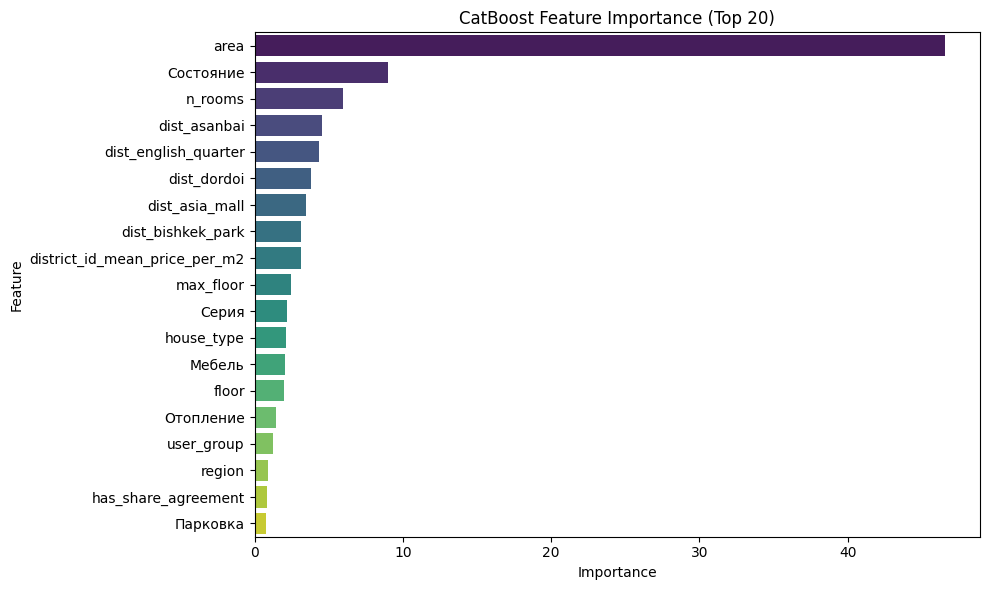

In [195]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Получаем важности
feature_importances = final_model.get_feature_importance()
feature_names = final_model.feature_names_

# Табличка с сортировкой
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

print(fi_df.head(20))  # топ-20 фичей

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=fi_df.head(40), palette="viridis")
plt.title("CatBoost Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [196]:
# 1. Предсказания на тестовом датасете
test_preds = np.expm1(final_model.predict(test_df))

# 2. Формируем датафрейм с результатами
# предполагаем, что у test_df есть колонка "id" (или индекс используем как id)
submission = pd.DataFrame({
    "id": test_df.index,    # или test_df["id"], если есть отдельная колонка
    "price_dollars": test_preds
})

# 3. Сохраняем в CSV
submission.to_csv("submission.csv", index=False)

print(submission.head())

   id  price_dollars
0   0   83578.299150
1   1   47960.942170
2   2   43916.795444
3   3   75530.302843
4   4   82256.750018


In [192]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

# ---- SMAPE ----
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0
    return np.mean(diff) * 100


# ----- таргет с лог-трансформацией -----
y = np.log1p(train_df["price_dollars"])
X = train_df.drop(columns=["price_dollars"])
cat_features = X.select_dtypes(include=["object"]).columns.tolist()


# ----- KFold -----
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_iters = []
smape_scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
    print(f"\n📂 Fold {fold+1}")

    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    valid_pool = Pool(X_val, y_val, cat_features=cat_features)

    model = CatBoostRegressor(
        iterations=4000,
        depth=8,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )
    model.fit(train_pool, eval_set=valid_pool, use_best_model=False)

    # поиск лучшей итерации по SMAPE
    min_smape, best_iter = 1e9, 0
    for it in range(100, model.tree_count_, 100):
        preds = np.expm1(model.predict(valid_pool, ntree_end=it))
        s = smape(np.expm1(y_val.values), preds)
        if s < min_smape:
            min_smape, best_iter = s, it

    print(f"Fold {fold+1}: best_iter={best_iter}, SMAPE={min_smape:.2f}")
    best_iters.append(best_iter)
    smape_scores.append(min_smape)

print("\n===== Итоги CV =====")
print(f"Средний SMAPE: {np.mean(smape_scores):.2f} ± {np.std(smape_scores):.2f}")
print(f"Рекомендуемое число итераций: {int(np.mean(best_iters))}")


📂 Fold 1
Fold 1: best_iter=3900, SMAPE=10.18

📂 Fold 2
Fold 2: best_iter=3600, SMAPE=10.35

📂 Fold 3
Fold 3: best_iter=3400, SMAPE=10.08

📂 Fold 4
Fold 4: best_iter=3800, SMAPE=10.27

📂 Fold 5
Fold 5: best_iter=3900, SMAPE=9.67

===== Итоги CV =====
Средний SMAPE: 10.11 ± 0.24
Рекомендуемое число итераций: 3720


In [194]:
# ----- Финальная модель -----
final_best_iter = int(np.mean(best_iters))

final_model = CatBoostRegressor(
    iterations=final_best_iter,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

final_model.fit(Pool(X, y, cat_features=cat_features))

0:	learn: 0.5163162	total: 11.7ms	remaining: 43.5s
200:	learn: 0.1348901	total: 2.36s	remaining: 41.3s
400:	learn: 0.1070928	total: 4.86s	remaining: 40.2s
600:	learn: 0.0901099	total: 7.44s	remaining: 38.6s
800:	learn: 0.0768111	total: 9.98s	remaining: 36.4s
1000:	learn: 0.0668319	total: 12.5s	remaining: 34.1s
1200:	learn: 0.0594521	total: 15.2s	remaining: 31.9s
1400:	learn: 0.0527896	total: 17.8s	remaining: 29.5s
1600:	learn: 0.0473597	total: 20.4s	remaining: 27.1s
1800:	learn: 0.0423124	total: 23s	remaining: 24.6s
2000:	learn: 0.0381141	total: 25.7s	remaining: 22.1s
2200:	learn: 0.0345745	total: 28.3s	remaining: 19.5s
2400:	learn: 0.0315162	total: 31s	remaining: 17s
2600:	learn: 0.0287284	total: 33.6s	remaining: 14.4s
2800:	learn: 0.0264405	total: 36.2s	remaining: 11.9s
3000:	learn: 0.0241928	total: 38.8s	remaining: 9.31s
3200:	learn: 0.0222130	total: 41.5s	remaining: 6.73s
3400:	learn: 0.0206328	total: 44.2s	remaining: 4.14s
3600:	learn: 0.0192264	total: 46.8s	remaining: 1.55s
3719:

In [ ]:
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
import numpy as np

# ----- SMAPE -----
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0
    return np.mean(diff) * 100


# ----- Данные -----
y = np.log1p(train_df["price_dollars"])
X = train_df.drop(columns=["price_dollars", "latitude", "longitude", "price_per_m2", "district_id"])
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# ----- CV -----
def cv_smape(params):
    """Функция для кросс-валидации и возврата SMAPE"""
    kf = KFold(shuffle=True, random_state=42)
    smape_scores = []

    for train_idx, valid_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        valid_pool = Pool(X_val, y_val, cat_features=cat_features)

        model = CatBoostRegressor(
            iterations=params["iterations"],
            depth=params["depth"],
            learning_rate=params["learning_rate"],
            l2_leaf_reg=params["l2_leaf_reg"],
            random_seed=42,
            loss_function="RMSE",
            verbose=False
        )

        model.fit(train_pool, eval_set=valid_pool, use_best_model=False)

        preds = np.expm1(model.predict(valid_pool))
        smape_score = smape(np.expm1(y_val.values), preds)
        smape_scores.append(smape_score)

    return np.mean(smape_scores)


# ----- Optuna Objective -----
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 1000, 4000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True)
    }

    score = cv_smape(params)
    return score   # SMAPE (меньше = лучше)


# ----- Запуск Optuna -----
study = optuna.create_study(direction="minimize")  # минимизируем SMAPE
study.optimize(objective, n_trials=30, timeout=3600)

print("\n✅ Лучшие параметры:", study.best_trial.params)
print("Лучший SMAPE:", study.best_value)